# What Are Variables, Random Variables, and Histograms

This notebook covers fundamental concepts in descriptive statistics:

1. **Variables**: Classification and types of variables.
2. **Random Variables**: Mathematical definitions of discrete and continuous random variables.
3. **Histograms**: How to visualize data distributions and interpret their shapes.

These concepts bridge raw data observations with mathematical modeling and probability.

## 1) What Is a Variable?

In statistics, a **variable** is any characteristic, number, or quantity that can be measured or counted. It is called a variable because its value can vary from one member of a population to another.

Variables are broadly classified into two categories:

### A. Qualitative (Categorical) Variables
These describe a quality or characteristic and cannot be measured numerically. They are subdivided into:
- **Nominal Variables**: Categories with no inherent order or ranking. 
  - *Examples*: Eye color (blue, green, brown), blood type (A, B, AB, O), country of residence.
- **Ordinal Variables**: Categories that have a logical order or ranking, but the difference between values is not quantifiable.
  - *Examples*: Customer satisfaction ratings (Low, Medium, High), education levels (High School, Bachelors, Masters, PhD).

### B. Quantitative (Numerical) Variables
These take numerical values and represent measurable quantities. They are subdivided into:
- **Discrete Variables**: Variables that can only take distinct, countable values (often integers).
  - *Examples*: Number of children in a family, number of cars in a parking lot, shoe size.
- **Continuous Variables**: Variables that can take an infinite number of values within a given range (measured on a continuous scale).
  - *Examples*: Height of a person, temperature, time taken to complete a task.

## 2) What Is a Random Variable?

A **random variable** (usually denoted by a capital letter like $X$) is a mathematical rule or function that assigns a numerical value to each outcome in the sample space of a random experiment.

Unlike a standard variable in algebra (which has a single, unknown value), a random variable can take on a set of different values, each associated with a specific probability.

### Core Types of Random Variables:

#### A. Discrete Random Variable
A random variable that takes on a countable number of distinct values.
- **Probability Mass Function (PMF)**: Gives the probability that a discrete random variable is exactly equal to a specific value.
  $$
  P(X = x) = p(x), \quad \text{where} \quad \sum p(x) = 1
  $$
- *Example*: Let $X$ be the sum of numbers when rolling two fair 6-sided dice. $X$ can take integer values from 2 to 12.

#### B. Continuous Random Variable
A random variable that takes on any value in an interval of real numbers.
- **Probability Density Function (PDF)**: A function $f(x)$ used to describe the probability distribution. The probability that $X$ lies in a specific interval $[a, b]$ is the area under $f(x)$ from $a$ to $b$:
  $$
  P(a \le X \le b) = \int_{a}^{b} f(x) \,dx, \quad \text{where} \quad \int_{-\infty}^{\infty} f(x) \,dx = 1
  $$
  *Note*: The probability of a continuous random variable taking an exact single value is always zero: $P(X = c) = 0$.

## 3) Histograms

A **histogram** is one of the most important graphical tools in descriptive statistics. It is used to summarize and visualize the distribution of a continuous or discrete dataset.

### How a Histogram is Constructed:
1. **Binning**: The range of data values is divided into small, consecutive, non-overlapping intervals called **bins** (or classes).
2. **Counting**: The number of data points (frequency) falling into each bin is calculated.
3. **Plotting**: Rectangles are drawn where:
   - The width of each bar represents the bin interval.
   - The height represents the **frequency** (count), **relative frequency** (proportion), or **density**.

### Shapes of Distributions:
By looking at a histogram, we can quickly understand the shape, center, and spread of the data:

- **Symmetric / Bell-Shaped**: The left and right halves are mirror images. The mean, median, and mode are roughly equal (e.g., Normal Distribution).
- **Right-Skewed (Positively Skewed)**: The tail extends further to the right. The mean is typically greater than the median (e.g., Household income).
- **Left-Skewed (Negatively Skewed)**: The tail extends further to the left. The mean is typically less than the median (e.g., Age at retirement).
- **Bimodal**: The distribution has two distinct peaks, indicating the presence of two different groups within the dataset.

## 4) Small Example and Simulation

Let's illustrate these concepts with two examples:

1. **Discrete Case**: Rolling two dice. The random variable $X$ is the sum of the face values. We will simulate 10,000 rolls, count the frequency of each sum, and visualize this discrete distribution.
2. **Continuous Case**: Height of individuals in a population. The random variable $Y \sim N(\mu, \sigma^2)$ is continuous. We will simulate a sample of 10,000 individuals with mean height $\mu = 170$ cm and standard deviation $\sigma = 10$ cm, and construct a histogram with a superimposed Gaussian density curve.

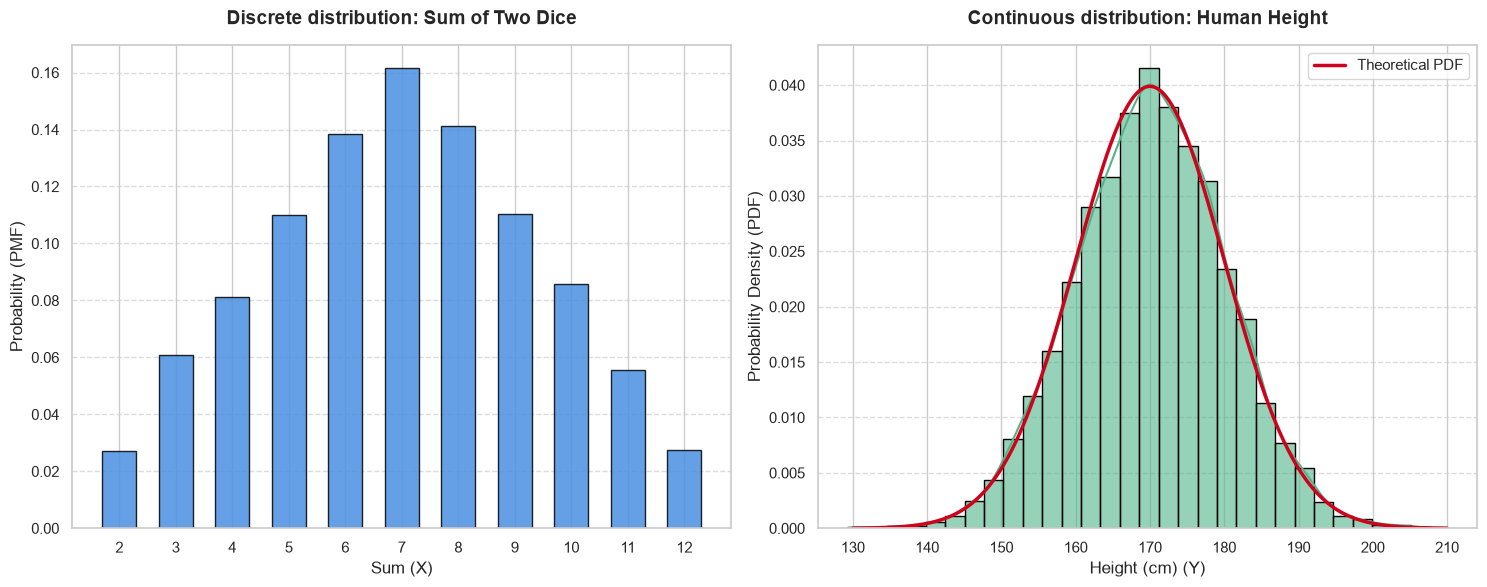

--- Simulation Summary ---
Discrete Variable (Sum of rolling two dice):
  Simulated Mean: 6.998 (Theoretical: 7.0)
  Simulated Variance: 5.897 (Theoretical: 5.833)

Continuous Variable (Human Height in cm):
  Simulated Mean: 170.139 cm (Target: 170 cm)
  Simulated Std Dev: 10.052 cm (Target: 10 cm)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Set seed for reproducibility
np.random.seed(42)

# 1. Discrete Random Variable Simulation: Roll 2 dice 10,000 times
rolls_1 = np.random.randint(1, 7, 10000)
rolls_2 = np.random.randint(1, 7, 10000)
sum_rolls = rolls_1 + rolls_2

# 2. Continuous Random Variable Simulation: Height of 10,000 people
heights = np.random.normal(loc=170, scale=10, size=10000)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Discrete Random Variable Histogram / Bar Plot
unique, counts = np.unique(sum_rolls, return_counts=True)
probabilities = counts / len(sum_rolls)

axes[0].bar(unique, probabilities, color='#4A90E2', edgecolor='black', alpha=0.85, width=0.6)
axes[0].set_title("Discrete distribution: Sum of Two Dice", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Sum (X)", fontsize=12)
axes[0].set_ylabel("Probability (PMF)", fontsize=12)
axes[0].set_xticks(range(2, 13))
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Continuous Random Variable Histogram with KDE
sns.histplot(heights, bins=30, stat="density", kde=True, ax=axes[1],
             color='#50B48A', edgecolor='black', alpha=0.6)

# Generate normal curve points to overlay on the histogram
x = np.linspace(130, 210, 200)
y = (1 / (10 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - 170)/10)**2)
axes[1].plot(x, y, color='#D0021B', linewidth=2.5, label='Theoretical PDF')

axes[1].set_title("Continuous distribution: Human Height", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Height (cm) (Y)", fontsize=12)
axes[1].set_ylabel("Probability Density (PDF)", fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print statistics summaries
print(f"--- Simulation Summary ---")
print(f"Discrete Variable (Sum of rolling two dice):")
print(f"  Simulated Mean: {np.mean(sum_rolls):.3f} (Theoretical: 7.0)")
print(f"  Simulated Variance: {np.var(sum_rolls):.3f} (Theoretical: 5.833)")
print(f'\nContinuous Variable (Human Height in cm):')
print(f"  Simulated Mean: {np.mean(heights):.3f} cm (Target: 170 cm)")
print(f"  Simulated Std Dev: {np.std(heights):.3f} cm (Target: 10 cm)")

## 5) Key Takeaways

- **Variables** represent characteristics that change across a population. They can be **Qualitative** (nominal/ordinal) or **Quantitative** (discrete/continuous).
- A **Random Variable** maps outcomes of a random process to real numbers.
- **Discrete Random Variables** are characterized by a **Probability Mass Function (PMF)**, which gives probabilities for individual values.
- **Continuous Random Variables** are characterized by a **Probability Density Function (PDF)**, where probabilities are defined over intervals (calculated as the area under the curve).
- **Histograms** are standard tools for analyzing the distribution of quantitative data, showing characteristics like shape (symmetry, skewness, bimodality), central tendency, and spread.